In [1]:
# 📥 Step 1: Load and Prepare Data
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Load datasets
fake_df = pd.read_csv(r"C:\Users\kabhi\OneDrive - Clark University\Desktop\Machine LEarning\ML_Project\News-_dataset\Fake.csv")
true_df = pd.read_csv(r"C:\Users\kabhi\OneDrive - Clark University\Desktop\Machine LEarning\ML_Project\News-_dataset\True.csv")

# Clean text
fake_df.dropna(subset=["text"], inplace=True)
true_df.dropna(subset=["text"], inplace=True)

# Add labels
fake_df["label"] = 0
true_df["label"] = 1


C:\Users\kabhi\AppData\Local\Temp\ipykernel_7428\451283204.py:11: DtypeWarning: Columns (4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171) have mixed types. Specify dtype option on import or set low_memory=False.
  fake_df = pd.read_csv(r"C:\Users\kabhi\OneDrive - Clark University\Desktop\Machine LEarning\ML_Project\News-_dataset\Fake.csv")


C:\Users\kabhi\AppData\Local\Temp\ipykernel_7428\3879370668.py:7: DtypeWarning: Columns (4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171) have mixed types. Specify dtype option on import or set low_memory=False.
  fake_df = pd.read_csv(r"C:\Users\kabhi\OneDrive - Clark University\Desktop\Machine LEarning\ML_Project\News-_dataset\Fake.csv")


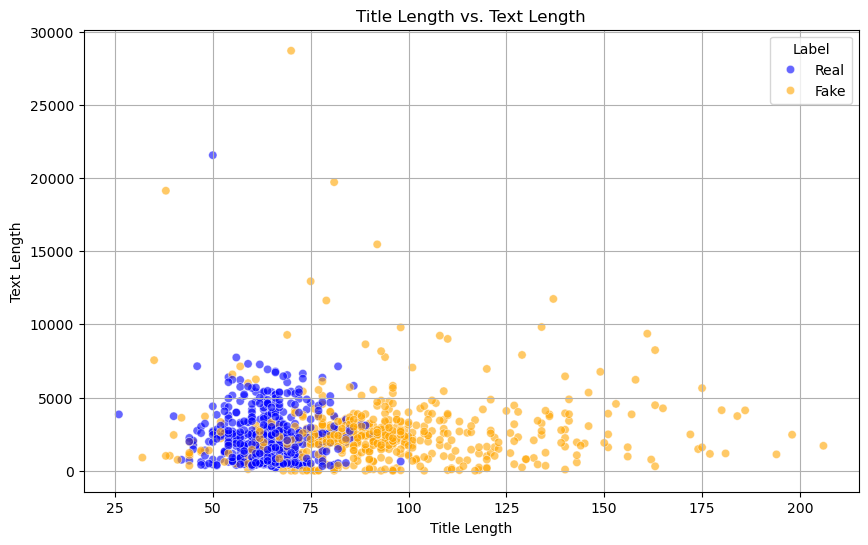

In [9]:
# 📥 Step 1: Load and Prepare Data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
fake_df = pd.read_csv(r"C:\Users\kabhi\OneDrive - Clark University\Desktop\Machine LEarning\ML_Project\News-_dataset\Fake.csv")
true_df = pd.read_csv(r"C:\Users\kabhi\OneDrive - Clark University\Desktop\Machine LEarning\ML_Project\News-_dataset\True.csv")

# Drop missing text entries
fake_df.dropna(subset=["text"], inplace=True)
true_df.dropna(subset=["text"], inplace=True)

# Assign labels
fake_df["label"] = 0  # Fake news
true_df["label"] = 1  # Real news

# ➕ Feature Engineering: Create text and title length features
fake_df["text_length"] = fake_df["text"].apply(lambda x: len(str(x)))
fake_df["title_length"] = fake_df["title"].apply(lambda x: len(str(x)))

true_df["text_length"] = true_df["text"].apply(lambda x: len(str(x)))
true_df["title_length"] = true_df["title"].apply(lambda x: len(str(x)))

# 🔀 Combine both datasets
combined_df = pd.concat([fake_df, true_df], ignore_index=True)

# 🧠 Convert numerical labels to string labels for plotting
combined_df["label"] = combined_df["label"].map({0: "Fake", 1: "Real"})

# 📊 Scatter Plot: Title Length vs Text Length with custom colors
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=combined_df.sample(1000),
    x='title_length',
    y='text_length',
    hue='label',
    alpha=0.6,
    palette={'Fake': 'orange', 'Real': 'blue'}
)
plt.title("Title Length vs. Text Length")
plt.xlabel("Title Length")
plt.ylabel("Text Length")
plt.legend(title='Label')
plt.grid(True)
plt.show()



C:\Users\kabhi\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


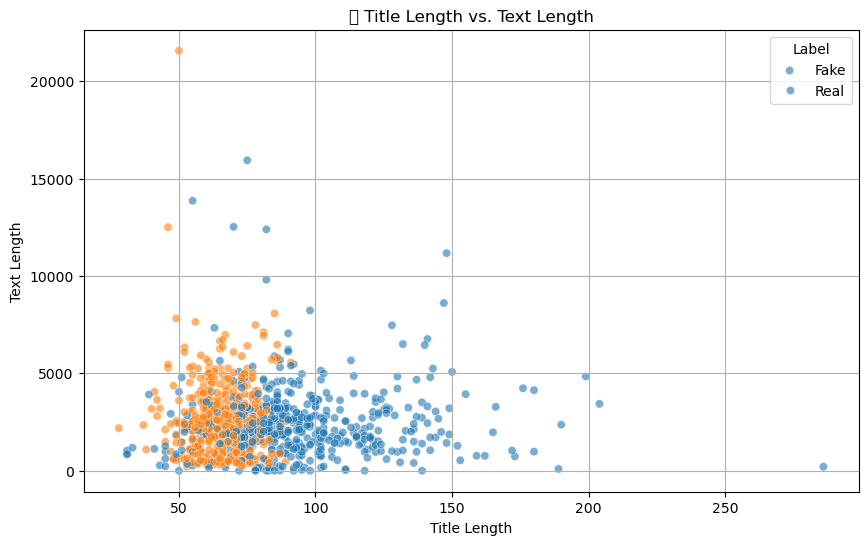

In [3]:
# 🎨 Scatter Plot: Title Length vs Text Length, colored by label
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=combined_df.sample(1000),
    x='title_length',
    y='text_length',
    hue='label',
    alpha=0.6,
    palette={'Fake': 'orange', 'Real': 'blue'}  # Custom colors
)
plt.title("📊 Title Length vs. Text Length")
plt.xlabel("Title Length")
plt.ylabel("Text Length")
plt.legend(title='Label')
plt.grid(True)
plt.show()


C:\Users\kabhi\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


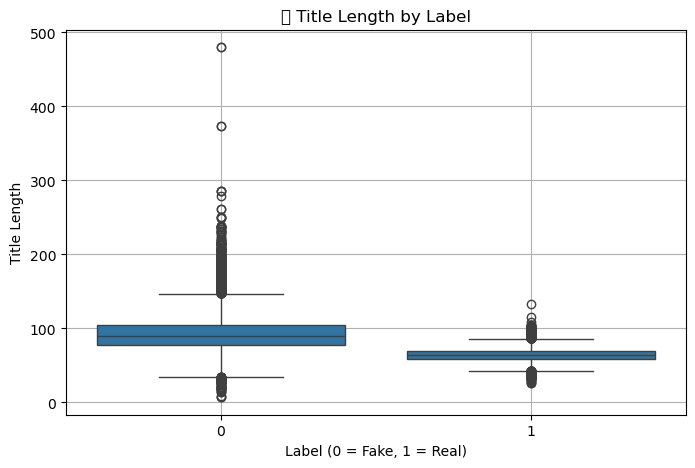

In [3]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='label', y='title_length', data=combined_df)
plt.title("📦 Title Length by Label")
plt.xlabel("Label (0 = Fake, 1 = Real)")
plt.ylabel("Title Length")
plt.grid(True)
plt.show()


In [4]:
!pip install wordcloud


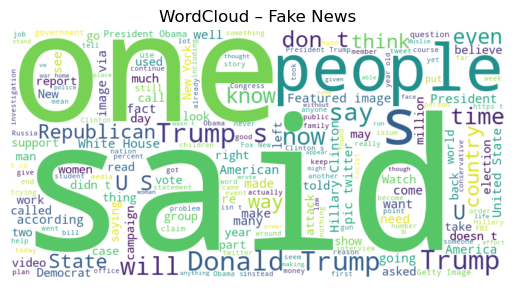

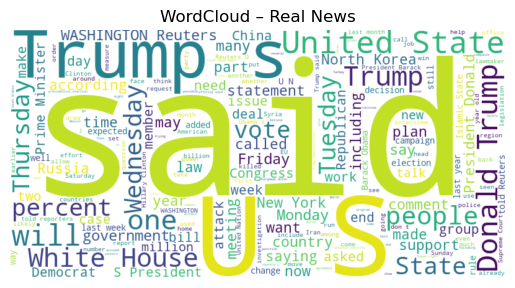

In [5]:
from wordcloud import WordCloud

fake_text = ' '.join(combined_df[combined_df['label'] == 0]['text'].astype(str))
real_text = ' '.join(combined_df[combined_df['label'] == 1]['text'].astype(str))

# Fake news cloud
wc_fake = WordCloud(width=800, height=400, background_color='white').generate(fake_text)
plt.imshow(wc_fake, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud – Fake News")
plt.show()

# Real news cloud
wc_real = WordCloud(width=800, height=400, background_color='white').generate(real_text)
plt.imshow(wc_real, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud – Real News")
plt.show()


In [6]:
# ✏️ Step 2: Sample Training and Testing Data

# 2500 true + 400 fake for training
true_train = true_df.sample(2500, random_state=42)
fake_train = fake_df.sample(400, random_state=42)
train_df = pd.concat([true_train, fake_train]).sample(frac=1, random_state=42)

X_train_text = train_df["text"]
y_train = train_df["label"]

# All other fake for testing
fake_test_df = fake_df.drop(fake_train.index)
X_test_text = fake_test_df["text"]
y_test = fake_test_df["label"]


In [7]:
# 🧠 Step 3: TF-IDF Vectorization
vectorizer = TfidfVectorizer(stop_words="english", max_df=0.7, max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train_text)
X_test_vec = vectorizer.transform(X_test_text)


In [8]:
# 🔍 Step 4: Train & Evaluate Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_vec, y_train)
log_preds = log_reg.predict(X_test_vec)

print("🧠 Logistic Regression Accuracy:", accuracy_score(y_test, log_preds))
print("Classification Report:\n", classification_report(y_test, log_preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, log_preds))


🧠 Logistic Regression Accuracy: 0.45563154705220327
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.46      0.63     23102
           1       0.00      0.00      0.00         0

    accuracy                           0.46     23102
   macro avg       0.50      0.23      0.31     23102
weighted avg       1.00      0.46      0.63     23102

Confusion Matrix:
 [[10526 12576]
 [    0     0]]


C:\Users\kabhi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\kabhi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\kabhi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [9]:
import numpy as np
import pandas as pd

# Get feature names and coefficients
feature_names = np.array(vectorizer.get_feature_names_out())
coefficients = log_reg.coef_[0]

# Top positive (REAL) and negative (FAKE) words
top_pos_idx = np.argsort(coefficients)[-20:]
top_neg_idx = np.argsort(coefficients)[:20]

# Create DataFrame
logistic_features = pd.DataFrame({
    "Top REAL Words": feature_names[top_pos_idx][::-1],
    "Coefficient (REAL)": coefficients[top_pos_idx][::-1],
    "Top FAKE Words": feature_names[top_neg_idx],
    "Coefficient (FAKE)": coefficients[top_neg_idx]
})

logistic_features.head(20)


,Top REAL Words,Coefficient (REAL),Top FAKE Words,Coefficient (FAKE)
0,washington,2.270612,com,-2.745887
1,republican,1.766654,featured,-2.590612
2,wednesday,1.556546,image,-2.462949
3,thursday,1.521688,hillary,-2.311242
4,minister,1.515090,just,-2.307936
5,tuesday,1.502216,america,-2.230645
6,government,1.488571,like,-2.077504
7,china,1.449755,watch,-2.053168
8,state,1.432783,black,-2.024091
9,monday,1.380135,https,-1.999383


In [10]:
# 🌲 Step 5: Train & Evaluate Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_vec, y_train)
rf_preds = rf.predict(X_test_vec)

print("🌲 Random Forest Accuracy:", accuracy_score(y_test, rf_preds))
print("Classification Report:\n", classification_report(y_test, rf_preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_preds))


🌲 Random Forest Accuracy: 0.6840966150116873
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.68      0.81     23102
           1       0.00      0.00      0.00         0

    accuracy                           0.68     23102
   macro avg       0.50      0.34      0.41     23102
weighted avg       1.00      0.68      0.81     23102

Confusion Matrix:
 [[15804  7298]
 [    0     0]]


C:\Users\kabhi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\kabhi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\kabhi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [11]:
# Get feature importances from Random Forest
rf_importances = rf.feature_importances_
top_rf_idx = np.argsort(rf_importances)[-20:]

rf_features = pd.DataFrame({
    "Top Words": feature_names[top_rf_idx][::-1],
    "Importance": rf_importances[top_rf_idx][::-1]
})

rf_features.head(20)


,Top Words,Importance
0,image,0.032548
1,com,0.029686
2,https,0.022184
3,pic,0.018880
4,featured,0.017152
5,getty,0.014530
6,images,0.013384
7,video,0.012582
8,watch,0.009740
9,doesn,0.009623


In [12]:
# ⚡ Step 6: Train & Evaluate XGBoost
xgb = XGBClassifier(use_label_encoder=False, eval_metric="logloss")
xgb.fit(X_train_vec, y_train)
xgb_preds = xgb.predict(X_test_vec)

print("⚡ XGBoost Accuracy:", accuracy_score(y_test, xgb_preds))
print("Classification Report:\n", classification_report(y_test, xgb_preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, xgb_preds))


C:\Users\kabhi\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:40:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


⚡ XGBoost Accuracy: 0.7994978789715176
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.80      0.89     23102
           1       0.00      0.00      0.00         0

    accuracy                           0.80     23102
   macro avg       0.50      0.40      0.44     23102
weighted avg       1.00      0.80      0.89     23102

Confusion Matrix:
 [[18470  4632]
 [    0     0]]


C:\Users\kabhi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\kabhi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\kabhi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [13]:
# Get feature importances from XGBoost
xgb_importances = xgb.feature_importances_
top_xgb_idx = np.argsort(xgb_importances)[-20:]

xgb_features = pd.DataFrame({
    "Top Words": feature_names[top_xgb_idx][::-1],
    "Importance": xgb_importances[top_xgb_idx][::-1]
})

xgb_features.head(20)


,Top Words,Importance
0,featured,0.088477
1,com,0.073524
2,story,0.036799
3,https,0.031135
4,breitbart,0.026405
5,months,0.024813
6,watch,0.023267
7,minister,0.019277
8,getty,0.018763
9,image,0.018253


In [14]:
def cohen_d(x, y):
    # Convert to numpy arrays
    x = np.array(x)
    y = np.array(y)

    # Calculate the pooled standard deviation
    pooled_std = np.sqrt(((x.std() ** 2) + (y.std() ** 2)) / 2)

    # Calculate effect size
    d = (x.mean() - y.mean()) / pooled_std
    return d

print("Cohen's d: Logistic vs Random Forest =", cohen_d(log_correct, rf_correct))
print("Cohen's d: Random Forest vs XGBoost  =", cohen_d(rf_correct, xgb_correct))
print("Cohen's d: Logistic vs XGBoost       =", cohen_d(log_correct, xgb_correct))



NameError: name 'log_correct' is not defined

In [ ]:
# 🧪 Function: Predict News Article with All Three Models

def classify_news_article(news_text):
    # Transform the input using the same TF-IDF vectorizer
    input_vec = vectorizer.transform([news_text])

    # Predict with each model
    log_result = log_reg.predict(input_vec)[0]
    rf_result = rf.predict(input_vec)[0]
    xgb_result = xgb.predict(input_vec)[0]

    # Map numeric result to label
    label_map = {0: "🟥 FAKE", 1: "🟩 REAL"}

    print("🔍 Prediction Results:")
    print("🧠 Logistic Regression:", label_map[log_result])
    print("🌲 Random Forest:       ", label_map[rf_result])
    print("⚡ XGBoost:             ", label_map[xgb_result])


In [ ]:
# Try it out
sample_news ="Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media.  The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year,  President Angry Pants tweeted.  2018 will be a great year for America! As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year. 2018 will be a great year for America!  Donald J. Trump (@realDonaldTrump) December 31, 2017Trump s tweet went down about as welll as you d expect.What kind of president sends a New Year s greeting like this despicable, petty, infantile gibberish? Only Trump! His lack of decency won t even allow him to rise above the gutter long enough to wish the American citizens a happy new year!  Bishop Talbert Swan (@TalbertSwan) December 31, 2017no one likes you  Calvin (@calvinstowell) December 31, 2017Your impeachment would make 2018 a great year for America, but I ll also accept regaining control of Congress.  Miranda Yaver (@mirandayaver) December 31, 2017Do you hear yourself talk? When you have to include that many people that hate you you have to wonder? Why do the they all hate me?  Alan Sandoval (@AlanSandoval13) December 31, 2017Who uses the word Haters in a New Years wish??  Marlene (@marlene399) December 31, 2017You can t just say happy new year?  Koren pollitt (@Korencarpenter) December 31, 2017Here s Trump s New Year s Eve tweet from 2016.Happy New Year to all, including to my many enemies and those who have fought me and lost so badly they just don t know what to do. Love!  Donald J. Trump (@realDonaldTrump) December 31, 2016This is nothing new for Trump. He s been doing this for years.Trump has directed messages to his  enemies  and  haters  for New Year s, Easter, Thanksgiving, and the anniversary of 9/11. pic.twitter.com/4FPAe2KypA  Daniel Dale (@ddale8) December 31, 2017Trump s holiday tweets are clearly not presidential.How long did he work at Hallmark before becoming President?  Steven Goodine (@SGoodine) December 31, 2017He s always been like this . . . the only difference is that in the last few years, his filter has been breaking down.  Roy Schulze (@thbthttt) December 31, 2017Who, apart from a teenager uses the term haters?  Wendy (@WendyWhistles) December 31, 2017he s a fucking 5 year old  Who Knows (@rainyday80) December 31, 2017So, to all the people who voted for this a hole thinking he would change once he got into power, you were wrong! 70-year-old men don t change and now he s a year older.Photo by Andrew Burton/Getty Images."
classify_news_article(sample_news)


In [ ]:
# 🧠 Load your new dataset (change path/column name as needed)
import pandas as pd

# Example: replace with your actual CSV or DataFrame name
new_data = pd.read_csv("TEST.csv")  # Or use your uploaded DataFrame if already loaded

# Make sure the column with news content exists
assert 'clean_text' in new_data.columns, "Missing 'text' column!"

# Use the right column (choose 'text' if available, else fallback to 'title')
clean_text_col = 'clean_text' if 'clean_text' in new_data.columns else 'title'

# 🧪 Transform using trained vectorizer
X_new_vec = vectorizer.transform(new_data[clean_text_col])

# 🔍 Predict using your preferred model (example: XGBoost)
new_data['prediction'] = xgb.predict(X_new_vec)
new_data['label'] = new_data['prediction'].map({0: '🟥 FAKE', 1: '🟩 REAL'})

# ✅ Show results
new_data[['clean_text', 'label']].head(15)


In [ ]:
new_data.to_csv("classified_news_outpu_yt.csv", index=False)
print("✅ Classified results saved as 'classified_news_output_x.csv'")


In [ ]:
# 🧠 Top 20 words based on XGBoost feature importance
xgb_words = [
    "featured", "com", "story", "https", "breitbart", "months", "watch", "minister", "getty", "image",
    "pic", "read", "business", "analysis", "gone", "video", "just", "talking", "democratic", "government"
]

# ✅ Reuse the same efficient count function
def count_words_efficient(text_series, words):
    word_set = set(words)
    word_counter = Counter()
    for text in text_series.dropna().astype(str):
        tokens = re.findall(r'\b\w+\b', text.lower())
        for token in tokens:
            if token in word_set:
                word_counter[token] += 1
    return [word_counter[word] for word in words]

# ✅ Load True and Fake data (if not already loaded)
true_df = pd.read_csv(r"C:\Users\kabhi\OneDrive - Clark University\Desktop\Machine LEarning\ML_Project\News-_dataset\True.csv")
fake_df = pd.read_csv(r"C:\Users\kabhi\OneDrive - Clark University\Desktop\Machine LEarning\ML_Project\News-_dataset\Fake.csv")
true_df.dropna(subset=["text"], inplace=True)
fake_df.dropna(subset=["text"], inplace=True)

# ✅ Count frequencies
xgb_true_counts = count_words_efficient(true_df["text"], xgb_words)
xgb_fake_counts = count_words_efficient(fake_df["text"], xgb_words)

# ✅ Create dataframe
df_xgb = pd.DataFrame({
    "Word": xgb_words,
    "Count in REAL news": xgb_true_counts,
    "Count in FAKE news": xgb_fake_counts
}).set_index("Word")

# ✅ Plot
df_xgb.plot(kind="bar", figsize=(14, 6), color=["skyblue", "salmon"])
plt.title("📊 Top 20 XGBoost Words - Frequency in REAL vs FAKE News")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()
